# ISAS Challenge: TSFEL + HistGradientBoosting

Thu tu pipeline: kiem tra du lieu, them dac trung pose, trich TSFEL, chay bon fold LOSO rieng cho S1/S2/S3/S5, train model cuoi tren ca bon subject, sau do du doan S4.

In [1]:
from pathlib import Path
import inspect, json, sys, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import sklearn, tsfel
from tsfel_histgb_pipeline import *
from train_tsfel_histgb import load_or_extract_subject

DATA_DIR = Path(r'E:\DATA\Keypoint\Train Data-20260812T151048Z-1-001\Train Data\keypointlabel')
TEST_FILE = Path(r'E:\DATA\Keypoint\test data_keypoint_shared.csv')
SUBJECTS = [1, 2, 3, 5]
PARTICIPANT_ID = 4
ARTIFACT_DIR = Path('artifacts/tsfel_histgb')
CACHE_DIR = ARTIFACT_DIR / 'cache'
OUTPUT_DIR = Path('outputs/tsfel_histgb')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Python:', sys.executable)
print('TSFEL:', getattr(tsfel, '__version__', '0.2.0'), '| sklearn:', sklearn.__version__)

Python: E:\Anaconda3\python.exe
TSFEL: 0.2.0 | sklearn: 1.7.2


## 1. Kiem tra schema va nhan

In [2]:
training_files = {s: DATA_DIR / f'keypoints_with_labels_{s}.csv' for s in SUBJECTS}
schema_rows = []
for subject, path in training_files.items():
    header = pd.read_csv(path, nrows=2)
    validate_pose_columns(header)
    assert 'Action Label' in header.columns
    schema_rows.append({'subject': subject, 'file': path.name, 'columns': len(header.columns)})
test_header = pd.read_csv(TEST_FILE, nrows=2)
validate_pose_columns(test_header)
display(pd.DataFrame(schema_rows))
print('Test columns:', len(test_header.columns), '| labeled:', 'Action Label' in test_header.columns)

,subject,file,columns
0,1,keypoints_with_labels_1.csv,36
1,2,keypoints_with_labels_2.csv,36
2,3,keypoints_with_labels_3.csv,36
3,5,keypoints_with_labels_5.csv,36


Test columns: 35 | labeled: False


## 2. Them dac trung pose truoc TSFEL

Buoc nay giu lai y tuong feature engineering cua v7, nhung chi dung cac tin hieu frame-level an toan cho LOSO. Khong dung cac thong ke tinh tren toan bo held-out subject va khong phu thuoc `custom_features.py`/`tsfel_feat.json`.

- Chuan hoa: tam tai midpoint hai hong, scale theo torso/shoulder.
- Hinh hoc: khoang cach vai, hong, goi, co chan, co tay-den-mui/hong.
- Tu the: goc elbow, knee, hip va center of mass.
- Chuyen dong: velocity dau, co tay, co chan, COM; acceleration co tay/dau.
- Tuong tac hanh vi: minimum wrist-to-nose distance va total movement.

In [3]:
# Day la ham feature engineering duoc goi that trong moi subject truoc TSFEL.
print(inspect.getsource(add_pose_signals))

def add_pose_signals(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    raw_joints = [
        "nose",
        "left_shoulder",
        "right_shoulder",
        "left_elbow",
        "right_elbow",
        "left_wrist",
        "right_wrist",
        "left_hip",
        "right_hip",
        "left_knee",
        "right_knee",
        "left_ankle",
        "right_ankle",
    ]
    raw_columns = [f"{joint}_{axis}" for joint in raw_joints for axis in ("x", "y")]

    distance_pairs = {
        "dist_shoulders": ("left_shoulder", "right_shoulder"),
        "dist_hips": ("left_hip", "right_hip"),
        "dist_knees": ("left_knee", "right_knee"),
        "dist_ankles": ("left_ankle", "right_ankle"),
        "dist_wrists": ("left_wrist", "right_wrist"),
        "dist_lw_nose": ("left_wrist", "nose"),
        "dist_rw_nose": ("right_wrist", "nose"),
        "dist_lw_lhip": ("left_wrist", "left_hip"),
        "dist_rw_rhip": ("right_wrist", "right_hip"),
    }
    for

In [4]:
preview_raw = pd.read_csv(training_files[1], nrows=900)
preview_prepared = prepare_pose_frame(preview_raw)
preview_normalized = pose_normalize(preview_prepared)
preview_enriched, signal_columns = add_pose_signals(preview_normalized)

raw_pose_signals = [c for c in signal_columns if c in COORD_COLUMNS]
engineered_signals = [c for c in signal_columns if c not in raw_pose_signals]
feature_audit = pd.DataFrame({
    'group': ['Normalized pose coordinates', 'Engineered frame-level signals', 'Total signals into TSFEL'],
    'count': [len(raw_pose_signals), len(engineered_signals), len(signal_columns)],
})
display(feature_audit)
print('Engineered signals:')
print(engineered_signals)
display(preview_enriched[engineered_signals].head())

,group,count
0,Normalized pose coordinates,26
1,Engineered frame-level signals,28
2,Total signals into TSFEL,54


Engineered signals:
['dist_shoulders', 'dist_hips', 'dist_knees', 'dist_ankles', 'dist_wrists', 'dist_lw_nose', 'dist_rw_nose', 'dist_lw_lhip', 'dist_rw_rhip', 'angle_elbow_l', 'angle_elbow_r', 'angle_knee_l', 'angle_knee_r', 'angle_hip_l', 'angle_hip_r', 'com_x', 'com_y', 'vel_nose', 'vel_left_wrist', 'vel_right_wrist', 'vel_left_ankle', 'vel_right_ankle', 'vel_com', 'acc_nose', 'acc_left_wrist', 'acc_right_wrist', 'min_dist_wrist_nose', 'total_movement']


,dist_shoulders,dist_hips,dist_knees,dist_ankles,dist_wrists,dist_lw_nose,dist_rw_nose,dist_lw_lhip,dist_rw_rhip,angle_elbow_l,...,vel_left_wrist,vel_right_wrist,vel_left_ankle,vel_right_ankle,vel_com,acc_nose,acc_left_wrist,acc_right_wrist,min_dist_wrist_nose,total_movement
0,0.199598,0.213207,0.480623,0.793865,0.111139,1.491062,1.402595,0.118722,0.208720,173.598093,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.402595,0.000000
1,0.209466,0.214975,0.501670,0.858086,0.118926,1.543566,1.436082,0.139138,0.182680,176.391263,...,0.062529,0.034279,0.033092,0.050231,0.006519,0.015758,0.062529,0.034279,1.436082,0.119085
2,0.215867,0.218714,0.518705,0.876942,0.101665,1.555534,1.474974,0.156246,0.117444,178.769826,...,0.067907,0.081974,0.043669,0.062257,0.003406,0.002753,0.005379,0.047695,1.474974,0.166293
3,0.231402,0.225714,0.523745,0.892468,0.088132,1.557171,1.504514,0.180257,0.075221,179.715575,...,0.060141,0.069070,0.040381,0.060138,0.006414,0.002123,0.007767,0.012904,1.504514,0.146508
4,0.245123,0.240456,0.505763,0.889169,0.102973,1.554998,1.497420,0.209859,0.043765,179.758644,...,0.045891,0.060672,0.052073,0.056259,0.007381,0.019988,0.014249,0.008398,1.497420,0.144815


## 3. Cau hinh TSFEL built-in

In [5]:
config = make_tsfel_config()
enabled = {domain: list(features) for domain, features in config.items()}
display(pd.DataFrame([(domain, name) for domain, names in enabled.items() for name in names], columns=['domain', 'feature']))
print('Pose signals:', len(signal_columns))
print('TSFEL functions per signal:', sum(len(v) for v in config.values()))
print('Expected final features:', len(signal_columns) * sum(len(v) for v in config.values()))

,domain,feature
0,statistical,Absolute energy
1,statistical,Interquartile range
2,statistical,Max
3,statistical,Mean
4,statistical,Median
5,statistical,Min
6,statistical,Peak to peak distance
7,statistical,Root mean square
8,statistical,Standard deviation
9,temporal,Area under the curve


Pose signals: 54
TSFEL functions per signal: 14
Expected final features: 756


## 4. Trich dac trung theo tung subject va cache

In [6]:
subject_windows = {}
for subject, path in training_files.items():
    subject_windows[subject] = load_or_extract_subject(path, subject, CACHE_DIR, config, force=False)

window_counts = pd.DataFrame({s: w.y.value_counts() for s, w in subject_windows.items()}).fillna(0).astype(int)
display(window_counts)
print('Feature matrix shapes:', {s: w.x.shape for s, w in subject_windows.items()})

Subject 1: loaded 963 cached windows with 756 features


Subject 2: loaded 945 cached windows with 756 features


Subject 3: loaded 1409 cached windows with 756 features


Subject 5: loaded 945 cached windows with 756 features


,1,2,3,5
Action Label,,,,
Attacking,58,76,69,59
Biting,73,37,118,74
Eating snacks,195,195,140,188
Head banging,50,52,80,52
Sitting quietly,190,195,365,198
Throwing things,59,52,49,51
Using phone,144,146,321,134
Walking,194,192,267,189


Feature matrix shapes: {1: (963, 756), 2: (945, 756), 3: (1409, 756), 5: (945, 756)}


## 5. LOSO theo bon cell rieng

Moi cell ben duoi train tren ba subject con lai va test tren mot subject held-out voi stride 150 frame, khong overlap trong tap test.

In [7]:
def show_loso_fold(fold):
    metric_row = {
        'held_out_subject': fold.held_out_subject,
        'n_train_windows': fold.n_train_windows,
        'n_test_windows': fold.n_test_windows,
        **fold.metrics,
    }
    display(pd.DataFrame([metric_row]))
    display(fold.classification_report)
    plt.figure(figsize=(10, 8))
    sns.heatmap(fold.confusion, annot=True, fmt='d', cmap='Blues')
    plt.title(f'LOSO confusion matrix - held-out S{fold.held_out_subject}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

### LOSO S1: test tren subject 1

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.520747,0.525221,0.789916,0.79661,0.783333


,precision,recall,f1-score,support
Attacking,0.200000,0.206897,0.203390,29.000000
Biting,1.000000,0.416667,0.588235,36.000000
Eating snacks,0.351351,0.663265,0.459364,98.000000
Head banging,1.000000,0.960000,0.979592,25.000000
Sitting quietly,0.120000,0.031579,0.050000,95.000000
Throwing things,0.612245,1.000000,0.759494,30.000000
Using phone,0.226415,0.166667,0.192000,72.000000
Walking,0.950495,0.989691,0.969697,97.000000
accuracy,0.520747,0.520747,0.520747,0.520747
macro avg,0.557563,0.554346,0.525221,482.000000


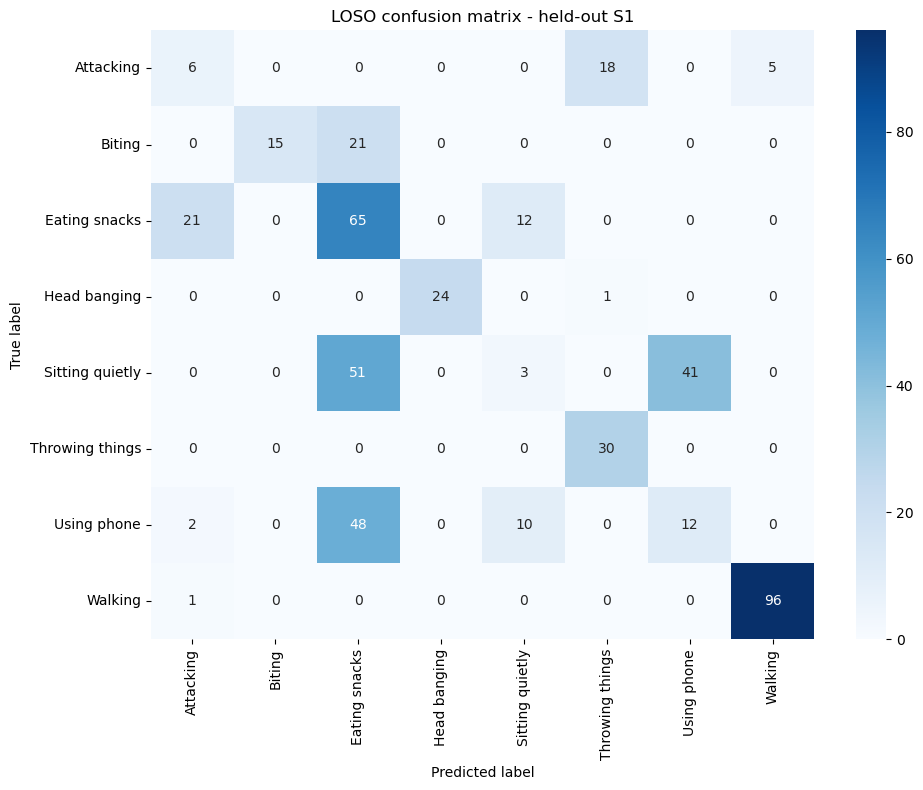

In [8]:
fold_s1 = run_loso_fold(subject_windows, held_out_subject=1, random_state=42)
fold_s1.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_1.csv')
show_loso_fold(fold_s1)

### LOSO S2: test tren subject 2

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,2,3317,472,0.680085,0.65373,0.763485,0.691729,0.851852


,precision,recall,f1-score,support
Attacking,1.000000,0.500000,0.666667,38.000000
Biting,0.310345,1.000000,0.473684,18.000000
Eating snacks,0.783333,0.484536,0.598726,97.000000
Head banging,0.812500,1.000000,0.896552,26.000000
Sitting quietly,0.544910,0.928571,0.686792,98.000000
Throwing things,0.875000,0.807692,0.840000,26.000000
Using phone,0.187500,0.041096,0.067416,73.000000
Walking,1.000000,1.000000,1.000000,96.000000
accuracy,0.680085,0.680085,0.680085,0.680085
macro avg,0.689199,0.720237,0.653730,472.000000


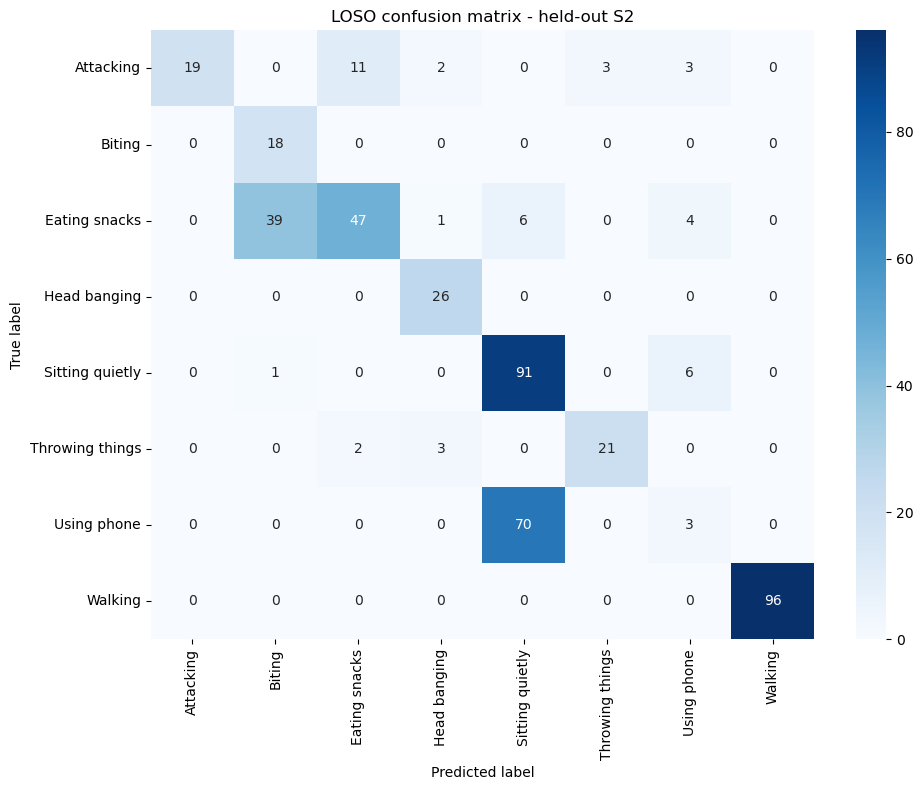

In [9]:
fold_s2 = run_loso_fold(subject_windows, held_out_subject=2, random_state=42)
fold_s2.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_2.csv')
show_loso_fold(fold_s2)

### LOSO S3: test tren subject 3

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,3,2853,703,0.43101,0.382154,0.484988,0.380435,0.66879


,precision,recall,f1-score,support
Attacking,0.580000,0.852941,0.690476,34.00000
Biting,0.123077,0.135593,0.129032,59.00000
Eating snacks,0.175000,0.100000,0.127273,70.00000
Head banging,1.000000,0.100000,0.181818,40.00000
Sitting quietly,0.935484,0.316940,0.473469,183.00000
Throwing things,0.121019,0.791667,0.209945,24.00000
Using phone,0.282051,0.343750,0.309859,160.00000
Walking,0.946154,0.924812,0.935361,133.00000
accuracy,0.431010,0.431010,0.431010,0.43101
macro avg,0.520348,0.445713,0.382154,703.00000


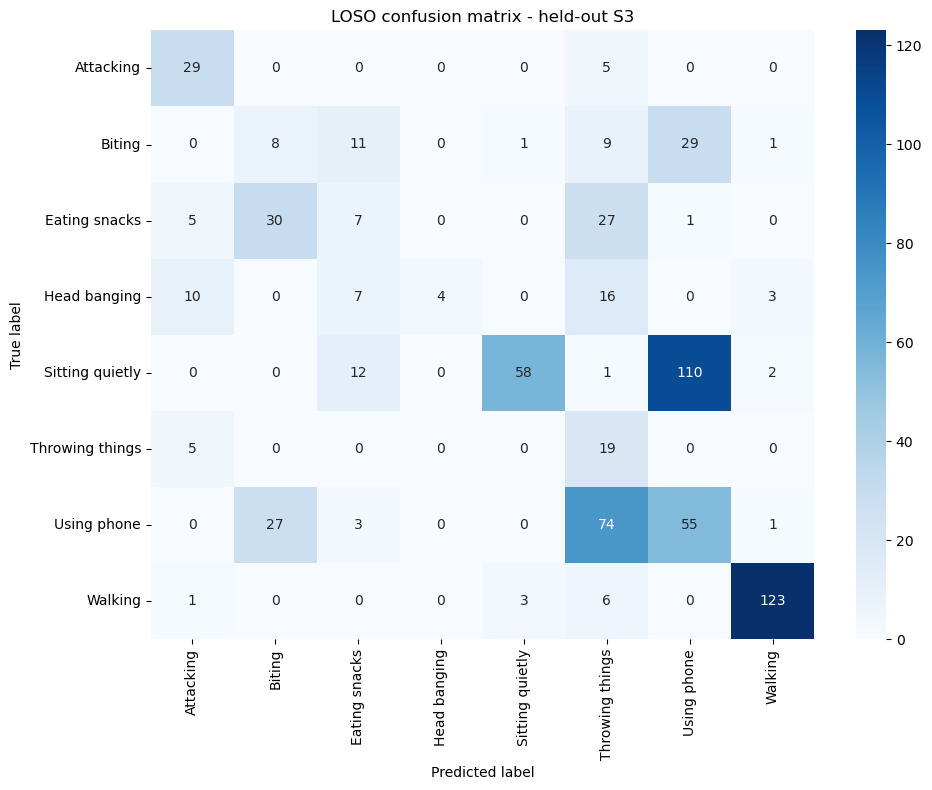

In [10]:
fold_s3 = run_loso_fold(subject_windows, held_out_subject=3, random_state=42)
fold_s3.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_3.csv')
show_loso_fold(fold_s3)

### LOSO S5: test tren subject 5

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,5,3317,471,0.660297,0.727975,0.982759,0.991304,0.974359


,precision,recall,f1-score,support
Attacking,1.000000,0.965517,0.982456,29.000000
Biting,0.972222,0.921053,0.945946,38.000000
Eating snacks,0.365546,0.925532,0.524096,94.000000
Head banging,1.000000,1.000000,1.000000,25.000000
Sitting quietly,0.416667,0.051020,0.090909,98.000000
Throwing things,0.961538,1.000000,0.980392,25.000000
Using phone,1.000000,0.176471,0.300000,68.000000
Walking,1.000000,1.000000,1.000000,94.000000
accuracy,0.660297,0.660297,0.660297,0.660297
macro avg,0.839497,0.754949,0.727975,471.000000


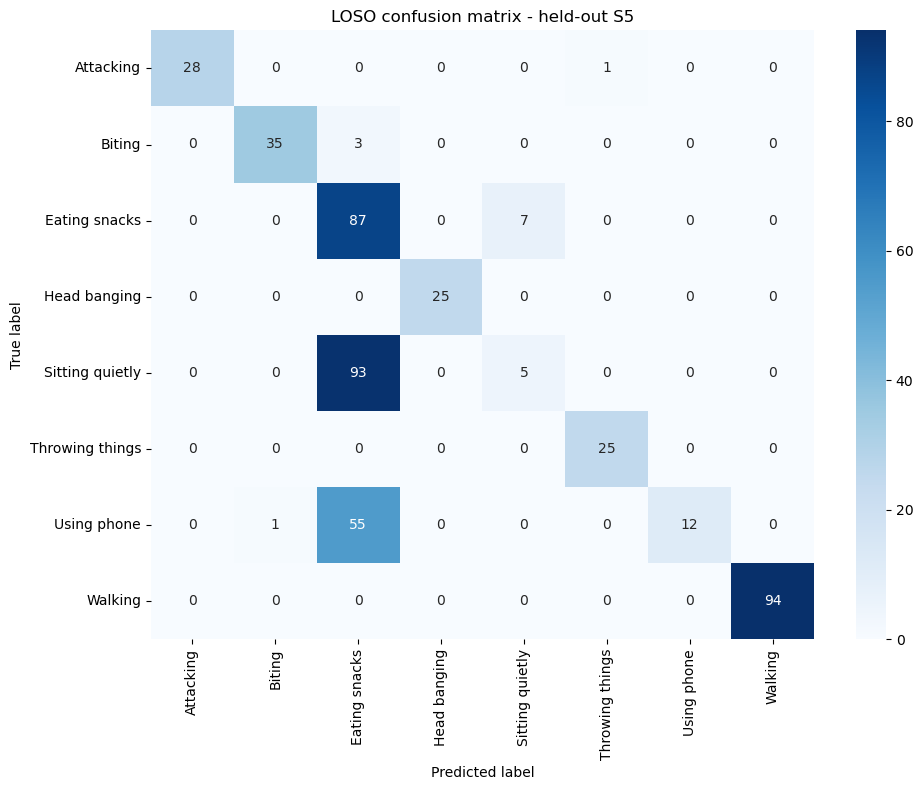

In [11]:
fold_s5 = run_loso_fold(subject_windows, held_out_subject=5, random_state=42)
fold_s5.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_5.csv')
show_loso_fold(fold_s5)

## 6. Tong hop bon fold LOSO

In [12]:
loso = combine_loso_folds([fold_s1, fold_s2, fold_s3, fold_s5])
loso.fold_metrics.to_csv(ARTIFACT_DIR / 'loso_fold_metrics.csv', index=False)
loso.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix.csv')
loso.classification_report.to_csv(ARTIFACT_DIR / 'loso_classification_report.csv')
(ARTIFACT_DIR / 'loso_summary.json').write_text(json.dumps(loso.summary, indent=2), encoding='utf-8')
display(loso.fold_metrics)
display(pd.Series(loso.summary, name='value').to_frame())

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.520747,0.525221,0.789916,0.796610,0.783333
1,2,3317,472,0.680085,0.653730,0.763485,0.691729,0.851852
2,3,2853,703,0.431010,0.382154,0.484988,0.380435,0.668790
3,5,3317,471,0.660297,0.727975,0.982759,0.991304,0.974359


,value
mean_fold_accuracy,0.573035
std_fold_accuracy,0.102445
mean_fold_macro_f1,0.572270
mean_fold_abnormal_f1,0.755287
pooled_accuracy,0.557331
pooled_macro_f1,0.566875
pooled_abnormal_f1,0.708042


## 7. Train model cuoi tren S1, S2, S3, S5 va xuat joblib

In [13]:
all_windows = concatenate_window_features([subject_windows[s] for s in SUBJECTS])
final_model = fit_estimator(all_windows)
artifact = build_artifact(final_model, all_windows.x.columns, metadata={
    'training_subjects': SUBJECTS,
    'training_files': {s: str(p.resolve()) for s, p in training_files.items()},
    'n_training_windows': len(all_windows.y),
    'class_window_counts': all_windows.y.value_counts().sort_index().to_dict(),
    'loso_summary': loso.summary,
})
MODEL_PATH = ARTIFACT_DIR / 'keypoint_tsfel_histgb_1_2_3_5.joblib'
save_artifact(MODEL_PATH, artifact)
print(MODEL_PATH.resolve(), MODEL_PATH.stat().st_size, 'bytes')

C:\Users\Tan\Documents\keypoint label\artifacts\tsfel_histgb\keypoint_tsfel_histgb_1_2_3_5.joblib 1759844 bytes


## 8. Nap lai artifact de kiem tra

In [14]:
artifact = load_artifact(MODEL_PATH)
assert artifact['metadata']['training_subjects'] == SUBJECTS
display(pd.Series({
    'architecture': artifact['architecture'],
    'features': len(artifact['feature_columns']),
    'training_windows': artifact['metadata']['n_training_windows'],
    'pooled_loso_accuracy': artifact['metadata']['loso_summary']['pooled_accuracy'],
}))

architecture            TSFEL+HistGradientBoosting
features                                       756
training_windows                              4262
pooled_loso_accuracy                      0.557331
dtype: object

## 9. Du doan shared test S4

In [15]:
test_frame = pd.read_csv(TEST_FILE)
prediction = predict_frame_labels(test_frame, artifact, participant_id=PARTICIPANT_ID)
paths = write_prediction_outputs(OUTPUT_DIR, test_frame, prediction, PARTICIPANT_ID)
display(pd.Series(prediction.frame_labels).value_counts().rename('frames').to_frame())
print('Filled:', paths.filled.resolve())
print('Submission:', paths.submission.resolve())

,frames
Biting,27450
Using phone,23400
Sitting quietly,19500
Walking,19500
Eating snacks,9000
Head banging,6900
Attacking,6600
Throwing things,5571


Filled: C:\Users\Tan\Documents\keypoint label\outputs\tsfel_histgb\test_data_keypoint_shared_predicted.csv
Submission: C:\Users\Tan\Documents\keypoint label\outputs\tsfel_histgb\submission_tsfel_histgb.csv


In [16]:
filled = pd.read_csv(paths.filled)
submission = pd.read_csv(paths.submission)
assert len(filled) == len(submission) == len(test_frame)
assert submission.columns.tolist() == ['participant_id', 'timestamp', 'predicted_label']
assert not submission.predicted_label.isna().any()
display(filled.head())
display(submission.head())

,frame_id,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,...,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,predicted_label,prediction_confidence
0,0,630.5,420.50,638.5,413.00,621.5,413.50,649.5,419.25,610.0,...,702.0,581.5,567.0,595.5,618.0,602.0,654.0,608.0,Sitting quietly,0.998366
1,1,629.5,421.75,637.5,414.00,620.5,414.50,648.5,420.25,609.0,...,702.0,581.5,567.0,595.5,618.0,601.5,654.5,608.0,Sitting quietly,0.998366
2,2,629.0,423.25,637.0,415.50,620.0,416.00,648.0,421.00,608.0,...,702.0,581.0,567.0,595.0,616.5,601.0,654.5,608.5,Sitting quietly,0.998366
3,3,628.5,424.25,636.5,416.50,619.5,417.25,647.0,421.50,607.0,...,702.0,580.5,567.0,594.0,617.0,601.5,653.5,608.5,Sitting quietly,0.998366
4,4,628.5,425.75,636.0,417.75,619.0,418.75,646.0,422.50,606.5,...,702.0,580.0,567.0,593.0,616.5,601.5,651.5,609.5,Sitting quietly,0.998366


,participant_id,timestamp,predicted_label
0,4,0,Sitting quietly
1,4,1,Sitting quietly
2,4,2,Sitting quietly
3,4,3,Sitting quietly
4,4,4,Sitting quietly


## 10. Test dataset moi

Dung `predict_tsfel_histgb.py --model artifacts/tsfel_histgb/keypoint_tsfel_histgb_1_2_3_5.joblib --input <file.csv> --participant-id <id>`.